# Precision-machining quality study

All production data and improvements are simulated. Performance indices use the overall sample standard deviation and are labeled **Pp/Ppk**, not within-subgroup Cp/Cpk. The mixed-machine, time-varying baseline is descriptive, not evidence of a stable normal process. Dates are synthetic day-level assignments, so the pooled I-MR chart is a methodology demonstration, not a validated production-control design. %GRR is the standard-deviation (study-variation) ratio for the sampled parts, not percent variance or an accuracy test.


In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

manufacturing = pd.read_csv(DATA_DIR / "manufacturing.csv")
gage_rr = pd.read_csv(DATA_DIR / "gage_rr.csv")

print("Manufacturing shape:", manufacturing.shape)
print("Gage R&R shape:", gage_rr.shape)
print(manufacturing.head())

Manufacturing shape: (20000, 14)
Gage R&R shape: (90, 5)
  Part_ID        Date Shift Machine Operator    Supplier  True_Diameter_mm  \
0  P00001  2026-02-18     C      M1       O2  Supplier A         19.979020   
1  P00002  2026-02-26     C      M4       O1  Supplier B         20.025342   
2  P00003  2026-02-08     A      M3       O1  Supplier C         20.248083   
3  P00004  2026-01-29     A      M2       O1  Supplier B         19.973769   
4  P00005  2026-01-05     A      M2       O1  Supplier A         19.992078   

   Diameter_mm  True_Length_mm  Length_mm  Temperature_C  Cycle_Time_sec  \
0    19.979344       49.930562  49.928169      23.166240       43.370526   
1    20.005780       49.912722  49.909828      19.200474       45.698370   
2    20.249524       49.746787  49.736253      25.864205       45.805003   
3    19.960088       50.056336  50.045699      19.175737       41.786459   
4    19.987427       50.062351  50.065143      23.012072       43.079518   

  Defect_Type Ins

In [2]:
parts = gage_rr["Part_ID"].unique()
operators = gage_rr["Operator"].unique()

n_parts = len(parts)
n_operators = len(operators)
n_trials = gage_rr["Trial"].nunique()

grand_mean = gage_rr["Diameter_mm"].mean()

part_means = gage_rr.groupby("Part_ID")["Diameter_mm"].mean()
operator_means = gage_rr.groupby("Operator")["Diameter_mm"].mean()
cell_means = gage_rr.groupby(["Part_ID", "Operator"])["Diameter_mm"].mean()

# Sum of squares
ss_part = (
    n_operators * n_trials
    * ((part_means - grand_mean) ** 2).sum()
)

ss_operator = (
    n_parts * n_trials
    * ((operator_means - grand_mean) ** 2).sum()
)

ss_interaction = n_trials * sum(
    (
        cell_means.loc[(part, operator)]
        - part_means.loc[part]
        - operator_means.loc[operator]
        + grand_mean
    ) ** 2
    for part, operator in cell_means.index
)

ss_repeatability = sum(
    (
        row["Diameter_mm"]
        - cell_means.loc[(row["Part_ID"], row["Operator"])]
    ) ** 2
    for _, row in gage_rr.iterrows()
)

# Degrees of freedom
df_part = n_parts - 1
df_operator = n_operators - 1
df_interaction = (n_parts - 1) * (n_operators - 1)
df_repeatability = n_parts * n_operators * (n_trials - 1)

# Mean squares
ms_part = ss_part / df_part
ms_operator = ss_operator / df_operator
ms_interaction = ss_interaction / df_interaction
ms_repeatability = ss_repeatability / df_repeatability

# Variance components
var_repeatability = ms_repeatability
var_interaction = max(
    (ms_interaction - ms_repeatability) / n_trials,
    0
)
var_operator = max(
    (ms_operator - ms_interaction) / (n_parts * n_trials),
    0
)
var_reproducibility = var_operator + var_interaction
var_part_to_part = max(
    (ms_part - ms_interaction) / (n_operators * n_trials),
    0
)

var_grr = var_repeatability + var_reproducibility
var_total = var_grr + var_part_to_part

percent_grr = 100 * np.sqrt(var_grr / var_total)
ndc = np.floor(
    1.41 * np.sqrt(var_part_to_part / var_grr)
)

msa_results = pd.DataFrame({
    "Variance Component": [
        var_repeatability,
        var_operator,
        var_interaction,
        var_reproducibility,
        var_part_to_part,
        var_grr,
        var_total,
    ]
}, index=[
    "Repeatability",
    "Operator",
    "Part × Operator Interaction",
    "Reproducibility",
    "Part-to-Part",
    "Total Gage R&R",
    "Total Variation",
])

display(msa_results)
print(f"%GRR: {percent_grr:.2f}%")
print(f"ndc: {int(ndc)}")

,Variance Component
Repeatability,0.000082
Operator,0.000014
Part × Operator Interaction,0.000000
Reproducibility,0.000014
Part-to-Part,0.011317
Total Gage R&R,0.000095
Total Variation,0.011413


%GRR: 9.13%
ndc: 15


### MSA interpretation

The crossed Gage R&R study produced a %GRR of approximately 9.13% and an ndc of 15. Under the project criteria, the measurement system is generally acceptable because %GRR is below 10% and ndc is greater than or equal to 5.

Repeatability is the largest gage contribution. Capability analysis will therefore proceed using the observed measurements, while recognizing that the observed variation includes a modest amount of measurement-system variation.


In [3]:
LSL_DIAMETER = 19.70
USL_DIAMETER = 20.30
LSL_LENGTH = 49.50
USL_LENGTH = 50.50

def capability_metrics(series, lsl, usl):
    mean = series.mean()
    std = series.std(ddof=1)

    cp = (usl - lsl) / (6 * std)
    cpu = (usl - mean) / (3 * std)
    cpl = (mean - lsl) / (3 * std)
    cpk = min(cpu, cpl)

    defective = ((series < lsl) | (series > usl)).sum()

    return {
        "Count": len(series),
        "Mean": mean,
        "Std Dev": std,
        "Pp": cp,
        "Ppk": cpk,
        "Defective": defective,
        "PPM": defective / len(series) * 1_000_000,
    }

overall_baseline = pd.DataFrame({
    "Diameter": capability_metrics(
        manufacturing["Diameter_mm"],
        LSL_DIAMETER,
        USL_DIAMETER,
    ),
    "Length": capability_metrics(
        manufacturing["Length_mm"],
        LSL_LENGTH,
        USL_LENGTH,
    ),
}).T

machine_baseline = pd.DataFrame({
    machine: capability_metrics(
        group["Diameter_mm"],
        LSL_DIAMETER,
        USL_DIAMETER,
    )
    for machine, group in manufacturing.groupby("Machine")
}).T

inspection_fail = manufacturing["Inspection_Result"].eq("Fail")

summary = pd.Series({
    "Total Parts": len(manufacturing),
    "Defective Parts": inspection_fail.sum(),
    "Defect Rate": inspection_fail.mean(),
    "PPM Defective": inspection_fail.mean() * 1_000_000,
    "First-Pass Yield": (~inspection_fail).mean(),
})

display(overall_baseline)
display(machine_baseline)
display(summary.to_frame("Value"))

,Count,Mean,Std Dev,Pp,Ppk,Defective,PPM
Diameter,20000.0,20.056703,0.102496,0.975652,0.791243,80.0,4000.0
Length,20000.0,50.001298,0.120778,1.379940,1.376356,2.0,100.0


,Count,Mean,Std Dev,Pp,Ppk,Defective,PPM
M1,5056.0,19.987178,0.032681,3.059904,2.929119,0.0,0.000000
M2,5016.0,20.002693,0.033622,2.974225,2.947525,0.0,0.000000
M3,5052.0,20.222625,0.035348,2.829004,0.729650,80.0,15835.312747
M4,4876.0,20.012446,0.032068,3.118391,2.989022,0.0,0.000000


,Value
Total Parts,20000.00000
Defective Parts,1065.00000
Defect Rate,0.05325
PPM Defective,53250.00000
First-Pass Yield,0.94675


In [4]:
import matplotlib.pyplot as plt

spc_data = (
    manufacturing
    .assign(Date=pd.to_datetime(manufacturing["Date"]))
    .sort_values(["Date", "Part_ID"])
    .reset_index(drop=True)
)

values = spc_data["Diameter_mm"].to_numpy()

individual_mean = values.mean()
moving_ranges = np.abs(np.diff(values))
mr_mean = moving_ranges.mean()

# For an individuals chart, sigma is estimated from average moving range.
sigma_estimate = mr_mean / 1.128

ucl_i = individual_mean + 3 * sigma_estimate
lcl_i = individual_mean - 3 * sigma_estimate

ucl_mr = 3.267 * mr_mean
lcl_mr = 0

print(f"Individuals center line: {individual_mean:.4f}")
print(f"Individuals UCL: {ucl_i:.4f}")
print(f"Individuals LCL: {lcl_i:.4f}")
print(f"Moving-range center line: {mr_mean:.4f}")

Individuals center line: 20.0567
Individuals UCL: 20.3415
Individuals LCL: 19.7719
Moving-range center line: 0.1071


In [5]:
def western_electric_rules(values, center, sigma):
    z = (values - center) / sigma
    n = len(values)

    flags = pd.DataFrame(False, index=range(n), columns=[
        "Rule 1: beyond 3 sigma",
        "Rule 2: 2 of 3 beyond 2 sigma",
        "Rule 3: 4 of 5 beyond 1 sigma",
        "Rule 4: 8 on one side",
    ])

    # Rule 1
    flags.iloc[:, 0] = np.abs(z) > 3

    # Rules 2–4
    for i in range(n):
        if i >= 2:
            window = z[i - 2:i + 1]
            flags.iloc[i, 1] = (
                (window > 2).sum() >= 2
                or (window < -2).sum() >= 2
            )

        if i >= 4:
            window = z[i - 4:i + 1]
            flags.iloc[i, 2] = (
                (window > 1).sum() >= 4
                or (window < -1).sum() >= 4
            )

        if i >= 7:
            window = z[i - 7:i + 1]
            flags.iloc[i, 3] = (
                (window > 0).all()
                or (window < 0).all()
            )

    flags["Any Signal"] = flags.any(axis=1)
    return flags

signals = western_electric_rules(
    values,
    individual_mean,
    sigma_estimate,
)

spc_data = pd.concat([spc_data, signals], axis=1)

signal_points = spc_data[spc_data["Any Signal"]].copy()

print(f"Total signaling points: {len(signal_points)}")
display(
    signal_points[
        [
            "Part_ID",
            "Date",
            "Machine",
            "Shift",
            "Diameter_mm",
            "Any Signal",
        ]
    ].head(20)
)

Total signaling points: 1941


,Part_ID,Date,Machine,Shift,Diameter_mm,Any Signal
21,P01161,2026-01-05,M3,A,20.245662,True
22,P01195,2026-01-05,M3,B,20.233700,True
23,P01217,2026-01-05,M3,C,20.225127,True
24,P01223,2026-01-05,M4,A,20.030825,True
62,P03792,2026-01-05,M1,C,19.940837,True
83,P05553,2026-01-05,M3,B,20.259802,True
84,P05598,2026-01-05,M3,A,20.194452,True
85,P05714,2026-01-05,M3,C,20.194788,True
86,P05726,2026-01-05,M2,A,20.046097,True
87,P05770,2026-01-05,M3,C,20.238312,True


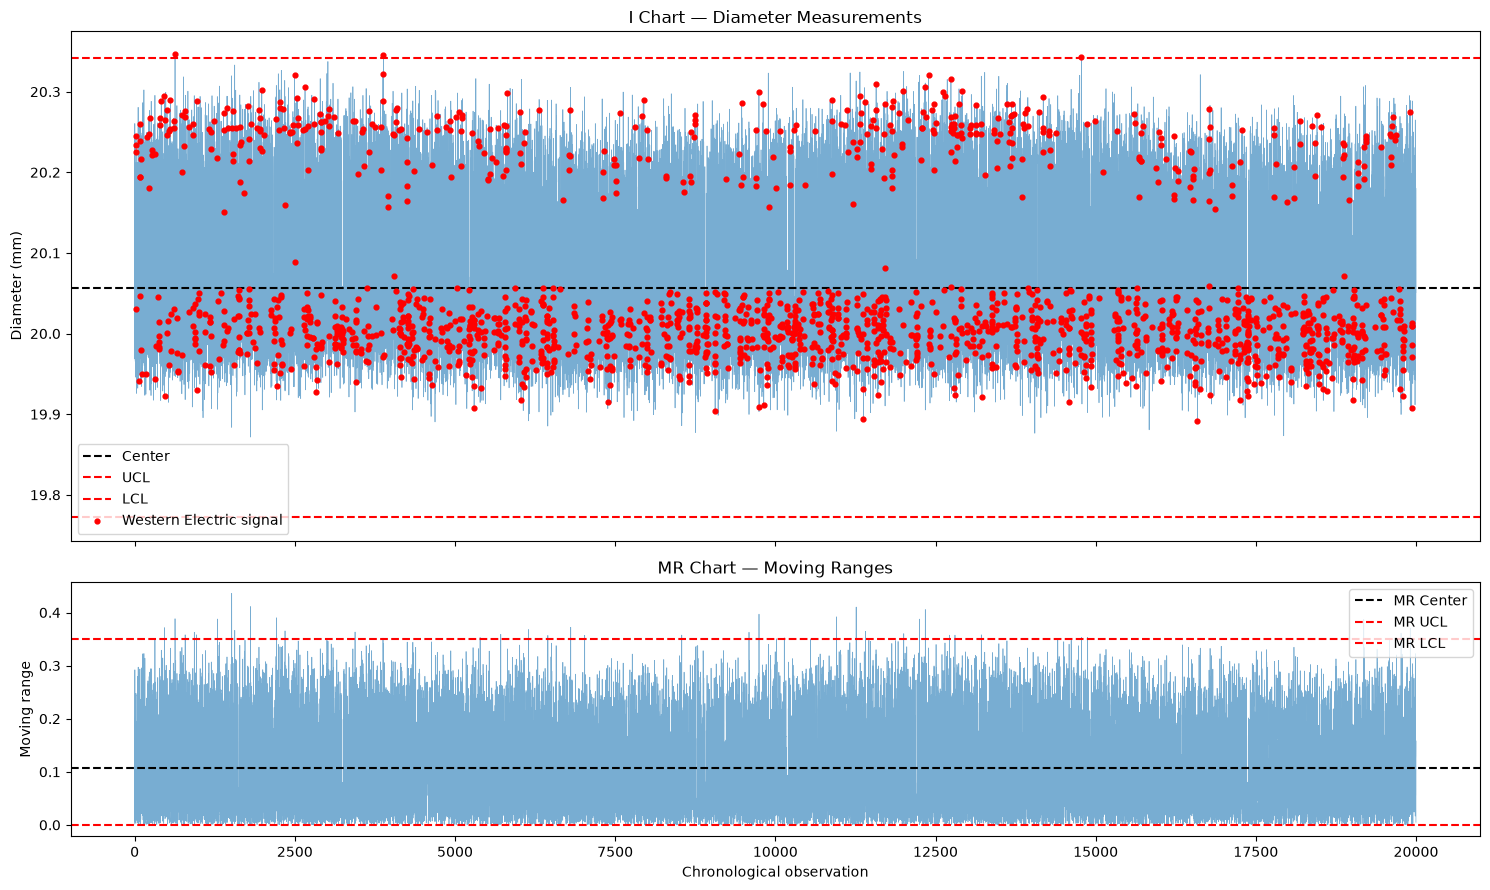

In [6]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

x = np.arange(len(values))

axes[0].plot(x, values, linewidth=0.5, alpha=0.6)
axes[0].axhline(individual_mean, color="black", linestyle="--", label="Center")
axes[0].axhline(ucl_i, color="red", linestyle="--", label="UCL")
axes[0].axhline(lcl_i, color="red", linestyle="--", label="LCL")

axes[0].scatter(
    x[signals["Any Signal"].to_numpy()],
    values[signals["Any Signal"].to_numpy()],
    color="red",
    s=12,
    label="Western Electric signal",
    zorder=3,
)

axes[0].set_title("I Chart — Diameter Measurements")
axes[0].set_ylabel("Diameter (mm)")
axes[0].legend()

axes[1].plot(
    np.arange(1, len(values)),
    moving_ranges,
    linewidth=0.5,
    alpha=0.6,
)
axes[1].axhline(mr_mean, color="black", linestyle="--", label="MR Center")
axes[1].axhline(ucl_mr, color="red", linestyle="--", label="MR UCL")
axes[1].axhline(lcl_mr, color="red", linestyle="--", label="MR LCL")

axes[1].set_title("MR Chart — Moving Ranges")
axes[1].set_xlabel("Chronological observation")
axes[1].set_ylabel("Moving range")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
### 3. Problem Identification

#This section uses Pareto analysis and stratification to identify where defects are concentrated before testing root-cause hypotheses.

In [8]:
defect_data = manufacturing[
    manufacturing["Defect_Type"] != "None"
].copy()

pareto = (
    defect_data["Defect_Type"]
    .value_counts()
    .rename_axis("Defect Type")
    .reset_index(name="Count")
)

pareto["Percent"] = pareto["Count"] / pareto["Count"].sum() * 100
pareto["Cumulative Percent"] = pareto["Percent"].cumsum()

display(pareto)

,Defect Type,Count,Percent,Cumulative Percent
0,Surface finish,407,38.215962,38.215962
1,Burr,211,19.812207,58.028169
2,Taper,206,19.342723,77.370892
3,Tool mark,161,15.117371,92.488263
4,Oversize,80,7.511737,100.000000


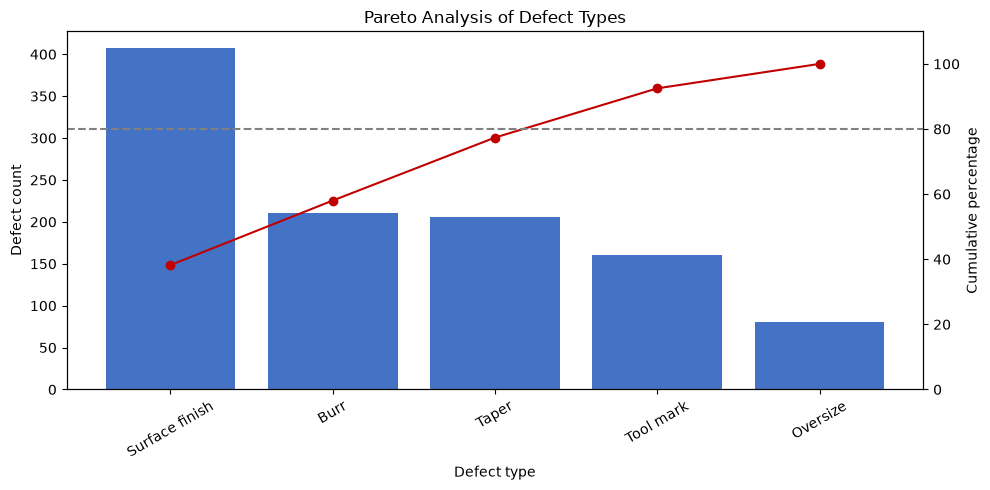

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    pareto["Defect Type"],
    pareto["Count"],
    color="#4472C4",
)

ax1.set_ylabel("Defect count")
ax1.set_xlabel("Defect type")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(
    pareto["Defect Type"],
    pareto["Cumulative Percent"],
    color="#C00000",
    marker="o",
)

ax2.axhline(80, color="gray", linestyle="--")
ax2.set_ylabel("Cumulative percentage")
ax2.set_ylim(0, 110)

plt.title("Pareto Analysis of Defect Types")
plt.tight_layout()
plt.show()

In [10]:
dimensional_defects = manufacturing["Defect_Type"].isin(
    ["Oversize", "Undersize"]
)

machine_summary = manufacturing.groupby("Machine").agg(
    Parts=("Part_ID", "size"),
    Defect_Rate=(
        "Inspection_Result",
        lambda s: (s == "Fail").mean()
    ),
    Dimensional_Defect_Rate=(
        "Defect_Type",
        lambda s: s.isin(["Oversize", "Undersize"]).mean()
    ),
)

shift_summary = manufacturing.groupby("Shift").agg(
    Parts=("Part_ID", "size"),
    Defect_Rate=(
        "Inspection_Result",
        lambda s: (s == "Fail").mean()
    ),
    Surface_Finish_Rate=(
        "Defect_Type",
        lambda s: (s == "Surface finish").mean()
    ),
)

supplier_summary = manufacturing.groupby("Supplier").agg(
    Parts=("Part_ID", "size"),
    Defect_Rate=(
        "Inspection_Result",
        lambda s: (s == "Fail").mean()
    ),
    Diameter_Std=("Diameter_mm", "std"),
)

display(machine_summary)
display(shift_summary)
display(supplier_summary)

,Parts,Defect_Rate,Dimensional_Defect_Rate
Machine,,,
M1,5056,0.046282,0.000000
M2,5016,0.052632,0.000000
M3,5052,0.065717,0.015835
M4,4876,0.048195,0.000000


,Parts,Defect_Rate,Surface_Finish_Rate
Shift,,,
A,6975,0.044875,0.013477
B,6904,0.047654,0.013470
C,6121,0.069106,0.035942


,Parts,Defect_Rate,Diameter_Std
Supplier,,,
Supplier A,6643,0.052687,0.101386
Supplier B,6660,0.057808,0.104554
Supplier C,6697,0.049276,0.101525


Shift,A,B,C
Machine,,,
M1,0.039798,0.040636,0.059720
M2,0.051402,0.037471,0.070175
M3,0.062185,0.061418,0.075203
M4,0.025384,0.050381,0.071864


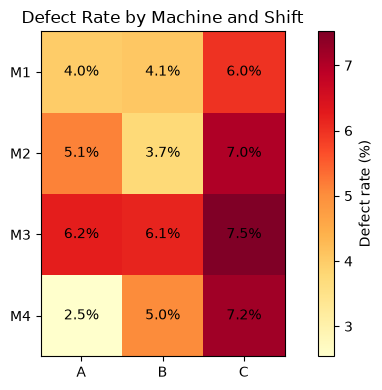

In [11]:
heatmap_data = manufacturing.pivot_table(
    index="Machine",
    columns="Shift",
    values="Inspection_Result",
    aggfunc=lambda s: (s == "Fail").mean(),
)

display(heatmap_data)

plt.figure(figsize=(7, 4))
plt.imshow(heatmap_data * 100, cmap="YlOrRd")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
)
plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index,
)

plt.colorbar(label="Defect rate (%)")
plt.title("Defect Rate by Machine and Shift")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        plt.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j] * 100:.1f}%",
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()

In [12]:
total_dimensional_defects = dimensional_defects.sum()
m3_dimensional_defects = (
    dimensional_defects
    & manufacturing["Machine"].eq("M3")
).sum()

m3_volume_share = (
    manufacturing["Machine"].eq("M3").mean()
)

m3_dimensional_defect_share = (
    m3_dimensional_defects / total_dimensional_defects
)

print(f"M3 production volume share: {m3_volume_share:.1%}")
print(
    "M3 share of dimensional defects: "
    f"{m3_dimensional_defect_share:.1%}"
)

M3 production volume share: 25.3%
M3 share of dimensional defects: 100.0%


In [13]:
## 4. Root-Cause Analysis

#The statistical tests below evaluate machine, temperature, shift, and supplier effects before developing the qualitative root-cause tools.

In [14]:
import sys
import sys
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

anova_model = ols(
    "Diameter_mm ~ C(Machine)",
    data=manufacturing,
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2,
)

display(anova_table)

machine_ss = anova_table.loc["C(Machine)", "sum_sq"]
total_ss = anova_table["sum_sq"].sum()
eta_squared = machine_ss / total_ss

print(f"Machine effect size, eta-squared: {eta_squared:.4f}")

,sum_sq,df,F,PR(>F)
C(Machine),187.703847,3.0,55871.820897,0.0
Residual,22.392481,19996.0,NaN,NaN


Machine effect size, eta-squared: 0.8934


In [15]:
regression_model = ols(
    "Diameter_mm ~ C(Machine) + Temperature_C + C(Shift) + C(Supplier)",
    data=manufacturing,
).fit()

print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Diameter_mm   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                 2.170e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:48:43   Log-Likelihood:                 39886.
No. Observations:               20000   AIC:                        -7.975e+04
Df Residuals:                   19991   BIC:                        -7.968e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [16]:
manufacturing["Diameter_Deviation_mm"] = (
    manufacturing["Diameter_mm"] - 20.00
)

temperature_correlations = (
    manufacturing
    .groupby("Machine")
    .apply(
        lambda group: group["Temperature_C"].corr(
            group["Diameter_Deviation_mm"]
        )
    )
    .rename("Temperature vs. Diameter Deviation Correlation")
    .to_frame()
)

display(temperature_correlations)

/var/folders/b7/433jvhln44x8gd6l9x_6tkwr0000gn/T/ipykernel_50337/1929383326.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Temperature vs. Diameter Deviation Correlation
Machine,
M1,0.070927
M2,0.112740
M3,0.394808
M4,0.089842


,sum_sq,df,F,PR(>F)
C(Machine),187.703847,3.0,55871.820897,0.0
Residual,22.392481,19996.0,NaN,NaN


Machine effect size, eta-squared: 0.8934
                            OLS Regression Results                            
Dep. Variable:            Diameter_mm   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                 2.170e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:48:43   Log-Likelihood:                 39886.
No. Observations:               20000   AIC:                        -7.975e+04
Df Residuals:                   19991   BIC:                        -7.968e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------


Regression with HC3 robust standard errors:
                            OLS Regression Results                            
Dep. Variable:            Diameter_mm   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                 2.123e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:48:43   Log-Likelihood:                 39886.
No. Observations:               20000   AIC:                        -7.975e+04
Df Residuals:                   19991   BIC:                        -7.968e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

,Correlation,P-value,Parts
Machine,,,
M1,0.070927,4.455221e-07,5056
M2,0.112740,1.164104e-15,5016
M3,0.394808,4.291267e-188,5052
M4,0.089842,3.287146e-10,4876


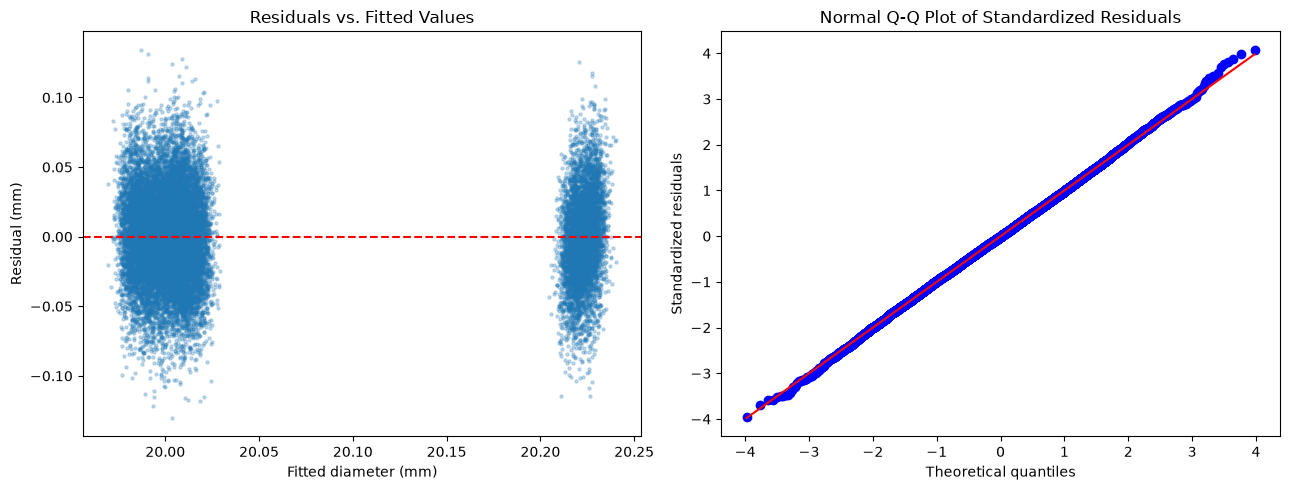

Shapiro-Wilk statistic: 0.9997
Shapiro-Wilk p-value: 0.6883

Breusch-Pagan statistic: 398.3542
Breusch-Pagan p-value: 4.213e-81

Compact root-cause summary
--------------------------
ANOVA machine p-value: 0
Machine eta-squared: 0.8934
Regression R-squared: 0.8967
Regression adjusted R-squared: 0.8967
Shapiro-Wilk p-value: 0.6883
Breusch-Pagan p-value: 4.213e-81


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan


# ------------------------------------------------------------
# 1. ANOVA: Does machine affect diameter?
# ------------------------------------------------------------

anova_model = ols(
    "Diameter_mm ~ C(Machine)",
    data=manufacturing,
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2,
)

display(anova_table)

machine_ss = anova_table.loc["C(Machine)", "sum_sq"]
residual_ss = anova_table.loc["Residual", "sum_sq"]
eta_squared = machine_ss / (machine_ss + residual_ss)

print(f"Machine effect size, eta-squared: {eta_squared:.4f}")


# ------------------------------------------------------------
# 2. Multiple regression
# ------------------------------------------------------------

manufacturing["Diameter_Deviation_mm"] = (
    manufacturing["Diameter_mm"] - 20.00
)

regression_model = ols(
    "Diameter_mm ~ C(Machine) + Temperature_C + C(Shift) + C(Supplier)",
    data=manufacturing,
).fit()

print(regression_model.summary())


# ------------------------------------------------------------
# 3. Robust regression sensitivity check
# ------------------------------------------------------------

robust_regression = regression_model.get_robustcov_results(
    cov_type="HC3"
)

print("\nRegression with HC3 robust standard errors:")
print(robust_regression.summary())


# ------------------------------------------------------------
# 4. Temperature correlation by machine
# ------------------------------------------------------------

correlation_rows = []

for machine, group in manufacturing.groupby("Machine"):
    correlation, p_value = stats.pearsonr(
        group["Temperature_C"],
        group["Diameter_Deviation_mm"],
    )

    correlation_rows.append({
        "Machine": machine,
        "Correlation": correlation,
        "P-value": p_value,
        "Parts": len(group),
    })

temperature_correlations = (
    pd.DataFrame(correlation_rows)
    .set_index("Machine")
)

display(temperature_correlations)


# ------------------------------------------------------------
# 5. Residual diagnostics
# ------------------------------------------------------------

residuals = regression_model.resid
fitted_values = regression_model.fittedvalues

standardized_residuals = (
    residuals - residuals.mean()
) / residuals.std(ddof=1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

# Residuals versus fitted values
axes[0].scatter(
    fitted_values,
    residuals,
    s=5,
    alpha=0.25,
)

axes[0].axhline(
    0,
    color="red",
    linestyle="--",
)

axes[0].set_title("Residuals vs. Fitted Values")
axes[0].set_xlabel("Fitted diameter (mm)")
axes[0].set_ylabel("Residual (mm)")


# Standardized normal probability plot
stats.probplot(
    standardized_residuals,
    dist="norm",
    plot=axes[1],
)

axes[1].set_title("Normal Q-Q Plot of Standardized Residuals")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Standardized residuals")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Formal assumption tests
# ------------------------------------------------------------

# Shapiro-Wilk is limited for very large datasets, so use a reproducible sample.
shapiro_sample = residuals.sample(
    min(5000, len(residuals)),
    random_state=42,
)

shapiro_statistic, shapiro_p_value = stats.shapiro(
    shapiro_sample
)

# Breusch-Pagan test for heteroscedasticity
bp_statistic, bp_p_value, _, _ = het_breuschpagan(
    residuals,
    regression_model.model.exog,
)

print(f"Shapiro-Wilk statistic: {shapiro_statistic:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p_value:.4g}")
print()
print(f"Breusch-Pagan statistic: {bp_statistic:.4f}")
print(f"Breusch-Pagan p-value: {bp_p_value:.4g}")


# ------------------------------------------------------------
# 7. Compact results summary
# ------------------------------------------------------------

print("\nCompact root-cause summary")
print("--------------------------")
print(
    f"ANOVA machine p-value: "
    f"{anova_table.loc['C(Machine)', 'PR(>F)']:.4g}"
)
print(f"Machine eta-squared: {eta_squared:.4f}")
print(f"Regression R-squared: {regression_model.rsquared:.4f}")
print(
    f"Regression adjusted R-squared: "
    f"{regression_model.rsquared_adj:.4f}"
)
print(f"Shapiro-Wilk p-value: {shapiro_p_value:.4g}")
print(f"Breusch-Pagan p-value: {bp_p_value:.4g}")

In [18]:
coefficient_summary = pd.DataFrame({
    "Coefficient": regression_model.params,
    "P-value": regression_model.pvalues,
})

display(coefficient_summary)

print("Temperature correlations by machine:")
display(temperature_correlations)

,Coefficient,P-value
Intercept,19.907270,0.000000e+00
C(Machine)[T.M2],0.015727,5.468906e-125
C(Machine)[T.M3],0.235529,0.000000e+00
C(Machine)[T.M4],0.025321,1.536625e-309
C(Shift)[T.B],0.001631,3.557107e-03
C(Shift)[T.C],0.003073,1.019416e-07
C(Supplier)[T.Supplier B],0.000395,4.890629e-01
C(Supplier)[T.Supplier C],-0.000229,6.875497e-01
Temperature_C,0.003559,4.317722e-134


Temperature correlations by machine:


,Correlation,P-value,Parts
Machine,,,
M1,0.070927,4.455221e-07,5056
M2,0.112740,1.164104e-15,5016
M3,0.394808,4.291267e-188,5052
M4,0.089842,3.287146e-10,4876


### Statistical root-cause findings

Machine is strongly associated with diameter variation. Relative to the M1 reference group, M3 has an adjusted diameter shift of approximately 0.236 mm. The machine effect is large, with eta-squared equal to 0.8934.

Temperature has a positive relationship with diameter, and the machine-specific correlations show that M3 has the strongest temperature relationship. Shift C has a small positive diameter offset. Supplier coefficients are not statistically significant for mean diameter, so supplier effects should be evaluated using variance comparisons rather than mean comparisons.

These findings support M3 setup/centering and thermal response as the leading statistical root-cause pathway. Because the data is simulated, this is a modeled explanation rather than a real production discovery. 
###

In [19]:
# Test whether the temperature slope differs by machine
temperature_interaction_model = ols(
    "Diameter_mm ~ C(Machine) * Temperature_C + C(Shift) + C(Supplier)",
    data=manufacturing,
).fit()

print(temperature_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Diameter_mm   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 1.616e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:48:43   Log-Likelihood:                 40099.
No. Observations:               20000   AIC:                        -8.017e+04
Df Residuals:                   19988   BIC:                        -8.008e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [20]:
supplier_groups = [
    group["Diameter_mm"].to_numpy()
    for _, group in manufacturing.groupby("Supplier")
]

levene_statistic, levene_p_value = stats.levene(
    *supplier_groups,
    center="median",
)

supplier_variation = (
    manufacturing
    .groupby("Supplier")["Diameter_mm"]
    .agg(["count", "mean", "std", "var"])
)

display(supplier_variation)

print(f"Levene statistic: {levene_statistic:.4f}")
print(f"Levene p-value: {levene_p_value:.4g}")

,count,mean,std,var
Supplier,,,,
Supplier A,6643,20.055733,0.101386,0.010279
Supplier B,6660,20.056758,0.104554,0.010932
Supplier C,6697,20.057611,0.101525,0.010307


Levene statistic: 5.8444
Levene p-value: 0.002901


In [21]:
manufacturing["Temperature_C_centered"] = (
    manufacturing["Temperature_C"]
    - manufacturing["Temperature_C"].mean()
)

centered_interaction_model = ols(
    "Diameter_mm ~ C(Machine) * Temperature_C_centered "
    "+ C(Shift) + C(Supplier)",
    data=manufacturing,
).fit()

print(centered_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Diameter_mm   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 1.616e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:48:43   Log-Likelihood:                 40099.
No. Observations:               20000   AIC:                        -8.017e+04
Df Residuals:                   19988   BIC:                        -8.008e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

# 5. Qualitative Root-Cause Analysis

### 6M Fishbone — Dominant Failure Mode: Diameter Oversize

| Category | Possible cause | Evidence or status |
|---|---|---|
| Man | Setup or offset entry error on M3 | Plausible contributor; not directly tested |
| Machine | M3 is centered high and has stronger temperature sensitivity | Supported by ANOVA, regression, and correlation |
| Method | No temperature-based offset compensation or warm-up verification | Modeled process-control gap |
| Material | Supplier B has higher diameter variation | Supported by Levene test; secondary contributor |
| Measurement | Operator bias and repeatability noise | Gage R&R is acceptable at 9.13% GRR; not the primary cause |
| Mother Nature / Environment | Temperature variation affects diameter, especially on M3 | Supported by M3 temperature interaction |

### 5-Why Analysis — Modeled M3 Diameter Oversize

1. **Why are oversize defects occurring?**  
   Because parts produced on M3 are frequently above the upper diameter specification.

2. **Why is M3 producing high diameters?**  
   Because M3 is modeled with a positive center offset and a stronger positive temperature response.

3. **Why does temperature create additional diameter drift on M3?**  
   Because the modeled M3 process is more thermally sensitive than the other machines.

4. **Why is the drift not corrected before more parts are produced?**  
   Because the modeled control method does not include temperature-based offset compensation or a sufficiently sensitive reaction rule.

5. **Why is that control method missing?**  
   Because the process-control design does not link M3 offset verification, thermal conditions, and sampling frequency into one closed-loop control plan.

**Modeled root cause:** M3 process centering error combined with machine-specific temperature sensitivity.

This is a modeled root cause in synthetic data, not a claim about a real production line.

## 6. Modeled Improvement Simulation

This section simulates process centering by changing the M3 center offset from approximately 20.22 mm to 20.00 mm. This is a modeled scenario, not a real production improvement.

In [22]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure the project root is available for importing generate_data.py
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from generate_data import generate_production_data


# Generate comparable before/after datasets using the same random seed.
baseline_simulation = generate_production_data(
    n_parts=20_000,
    seed=42,
    process_centered=False,
)

modeled_centered_simulation = generate_production_data(
    n_parts=20_000,
    seed=42,
    process_centered=True,
)


def summarize_process(data, label):
    diameter = data["Diameter_mm"]
    failure = data["Inspection_Result"].eq("Fail")

    mean = diameter.mean()
    std = diameter.std(ddof=1)

    cp = (USL_DIAMETER - LSL_DIAMETER) / (6 * std)

    cpu = (USL_DIAMETER - mean) / (3 * std)
    cpl = (mean - LSL_DIAMETER) / (3 * std)
    cpk = min(cpu, cpl)

    m3_diameter = data.loc[
        data["Machine"].eq("M3"),
        "Diameter_mm",
    ]

    m3_mean = m3_diameter.mean()
    m3_std = m3_diameter.std(ddof=1)

    m3_cp = (
        (USL_DIAMETER - LSL_DIAMETER)
        / (6 * m3_std)
    )

    m3_cpu = (USL_DIAMETER - m3_mean) / (3 * m3_std)
    m3_cpl = (m3_mean - LSL_DIAMETER) / (3 * m3_std)
    m3_cpk = min(m3_cpu, m3_cpl)

    return {
        "Scenario": label,
        "Overall Mean Diameter": mean,
        "Overall Std Dev": std,
        "Overall Pp": cp,
        "Overall Ppk": cpk,
        "M3 Mean Diameter": m3_mean,
        "M3 Ppk": m3_cpk,
        "Defect Rate": failure.mean(),
        "PPM Defective": failure.mean() * 1_000_000,
        "First-Pass Yield": (~failure).mean(),
    }


improvement_comparison = pd.DataFrame([
    summarize_process(
        baseline_simulation,
        "Baseline process",
    ),
    summarize_process(
        modeled_centered_simulation,
        "Modeled M3 centering",
    ),
])

display(
    improvement_comparison.style.format({
        "Overall Mean Diameter": "{:.4f}",
        "Overall Std Dev": "{:.4f}",
        "Overall Pp": "{:.3f}",
        "Overall Ppk": "{:.3f}",
        "M3 Mean Diameter": "{:.4f}",
        "M3 Ppk": "{:.3f}",
        "Defect Rate": "{:.2%}",
        "PPM Defective": "{:,.0f}",
        "First-Pass Yield": "{:.2%}",
    })
)

,Scenario,Overall Mean Diameter,Overall Std Dev,Overall Pp,Overall Ppk,M3 Mean Diameter,M3 Ppk,Defect Rate,PPM Defective,First-Pass Yield
0,Baseline process,20.0567,0.1025,0.976,0.791,20.2226,0.730,5.33%,"53,250",94.67%
1,Modeled M3 centering,20.0011,0.0347,2.885,2.874,20.0026,2.804,4.95%,"49,500",95.05%


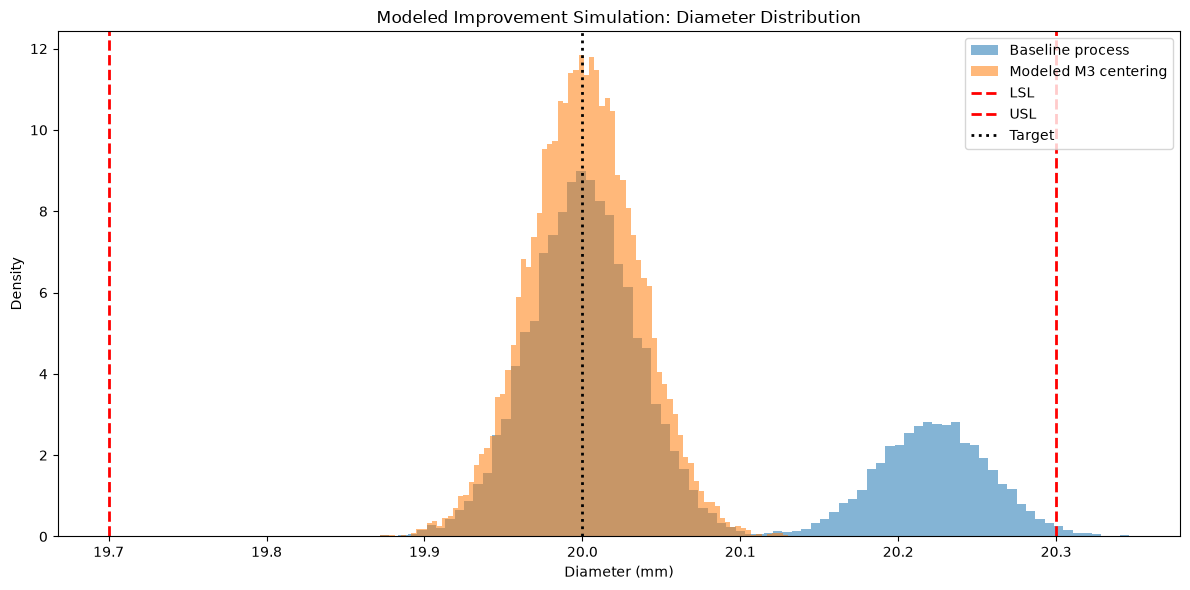

In [23]:
plt.figure(figsize=(12, 6))

plt.hist(
    baseline_simulation["Diameter_mm"],
    bins=80,
    density=True,
    alpha=0.55,
    label="Baseline process",
)

plt.hist(
    modeled_centered_simulation["Diameter_mm"],
    bins=80,
    density=True,
    alpha=0.55,
    label="Modeled M3 centering",
)

plt.axvline(
    LSL_DIAMETER,
    color="red",
    linestyle="--",
    linewidth=2,
    label="LSL",
)

plt.axvline(
    USL_DIAMETER,
    color="red",
    linestyle="--",
    linewidth=2,
    label="USL",
)

plt.axvline(
    20.00,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Target",
)

plt.xlabel("Diameter (mm)")
plt.ylabel("Density")
plt.title(
    "Modeled Improvement Simulation: Diameter Distribution"
)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Part 1 Conclusions

The measurement system was acceptable, with %GRR of approximately 9.13% and ndc of 15.

Machine was the dominant source of diameter variation. M3 was centered high and had the strongest temperature response. Shift C showed a higher surface-finish defect rate, while Supplier B showed modestly higher dimensional variation rather than a meaningful mean shift.

The modeled M3-centering scenario improved dimensional capability substantially. This result represents a simulated process change and must not be described as a real production improvement.

The proposed PFMEA and control plan translate these findings into prioritized risks, monitoring methods, sampling frequencies, and reaction plans.